In [1]:
import numpy as np
import pandas as pd
from numpy import log2 as log

In [2]:
#df=pd.read_csv('/content/play_tennis.csv')
#df = df.drop('day',axis=1)

In [3]:
from sklearn import preprocessing

data = {}
outlook = ["sunny", "sunny", "overcast", "rain", "rain", "rain", "overcast", "sunny", "sunny", "rain"]
temp = ["hot", "hot", "hot", "mild", "cool", "cool", "cool", "mild", "cool", "mild"]
humidity = ["high", "high", "high", "high", "normal", "normal", "normal", "high", "normal", "normal"]
wind = ["weak", "strong", "weak", "weak", "weak", "strong", "strong", "weak", "weak", "weak"]
playtennis = ["no", "no", "yes", "yes", "yes", "no", "yes", "no", "yes", "yes"]


data['outlook'] = outlook
data['temp'] = temp
data['humidity'] = humidity
data['wind'] = wind
data['playtennis'] = playtennis

print(data)

df = pd.DataFrame(data)
print(df)



{'outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain'], 'temp': ['hot', 'hot', 'hot', 'mild', 'cool', 'cool', 'cool', 'mild', 'cool', 'mild'], 'humidity': ['high', 'high', 'high', 'high', 'normal', 'normal', 'normal', 'high', 'normal', 'normal'], 'wind': ['weak', 'strong', 'weak', 'weak', 'weak', 'strong', 'strong', 'weak', 'weak', 'weak'], 'playtennis': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes']}
    outlook  temp humidity    wind playtennis
0     sunny   hot     high    weak         no
1     sunny   hot     high  strong         no
2  overcast   hot     high    weak        yes
3      rain  mild     high    weak        yes
4      rain  cool   normal    weak        yes
5      rain  cool   normal  strong         no
6  overcast  cool   normal  strong        yes
7     sunny  mild     high    weak         no
8     sunny  cool   normal    weak        yes
9      rain  mild   normal    weak        yes


In [4]:
df.head(14)

,outlook,temp,humidity,wind,playtennis
0,sunny,hot,high,weak,no
1,sunny,hot,high,strong,no
2,overcast,hot,high,weak,yes
3,rain,mild,high,weak,yes
4,rain,cool,normal,weak,yes
5,rain,cool,normal,strong,no
6,overcast,cool,normal,strong,yes
7,sunny,mild,high,weak,no
8,sunny,cool,normal,weak,yes
9,rain,mild,normal,weak,yes


In [5]:
df.describe()

,outlook,temp,humidity,wind,playtennis
count,10,10,10,10,10
unique,3,3,2,2,2
top,sunny,cool,high,weak,yes
freq,4,4,5,7,6


In [6]:
le = preprocessing.LabelEncoder()

df2 = df.apply(le.fit_transform)
print("TRAIN DATA: \n", df2)

testdata = {}

outlook2 = ["sunny", "overcast", "overcast", "rain"]
temp2 = ["mild", "mild", "hot", "mild"]
humidity2 = ["normal", "high", "normal", "high"]
wind2 = ["strong", "strong", "weak", "strong"]
playtennis2 = ["yes", "yes", "yes", "no"]


testdata['outlook'] = outlook2
testdata['temp'] = temp2
testdata['humidity'] = humidity2
testdata['wind'] = wind2
testdata['playtennis'] = playtennis2

test = pd.DataFrame(testdata)
le2 = preprocessing.LabelEncoder()

test = test.apply(le2.fit_transform)
print("TEST DATA: \n", test)









             


TRAIN DATA: 
    outlook  temp  humidity  wind  playtennis
0        2     1         0     1           0
1        2     1         0     0           0
2        0     1         0     1           1
3        1     2         0     1           1
4        1     0         1     1           1
5        1     0         1     0           0
6        0     0         1     0           1
7        2     2         0     1           0
8        2     0         1     1           1
9        1     2         1     1           1
TEST DATA: 
    outlook  temp  humidity  wind  playtennis
0        2     1         1     0           1
1        0     1         0     0           1
2        0     0         1     1           1
3        1     1         0     0           0


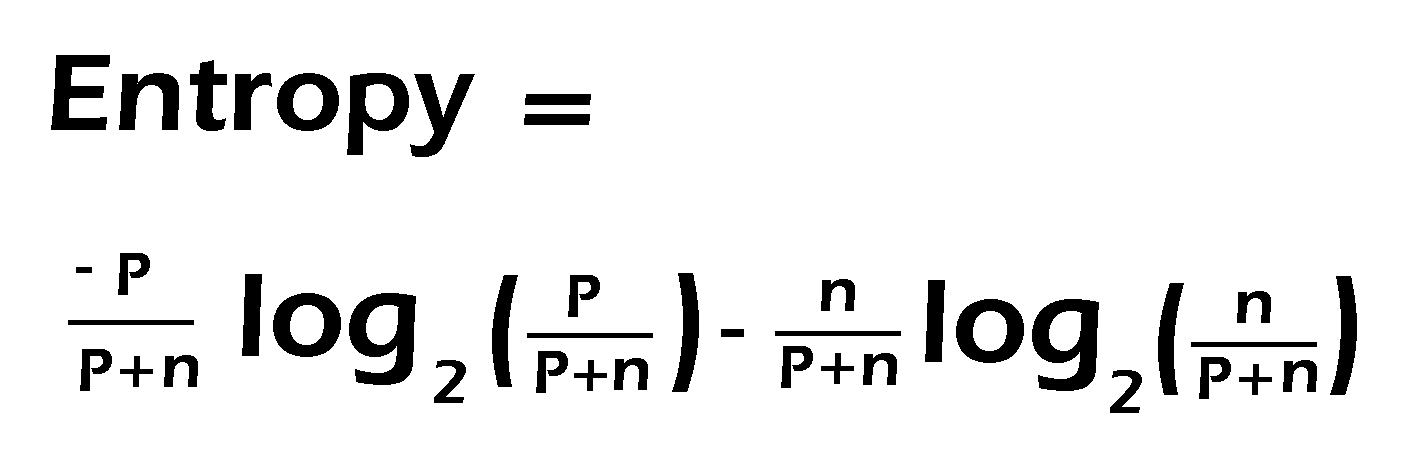

In [7]:
from numpy import log2 as log

def find_entropy(df):
    p = df[df['playtennis'] == 1].shape[0]
    total = df.shape[0]
    n = total - p

    if(p == 0 or p == total):
        return 0

    if(p == n):
        return 1

    entropy = -(p/total) * log(p/total) - (n/total) * log(n/total)
    
    return entropy


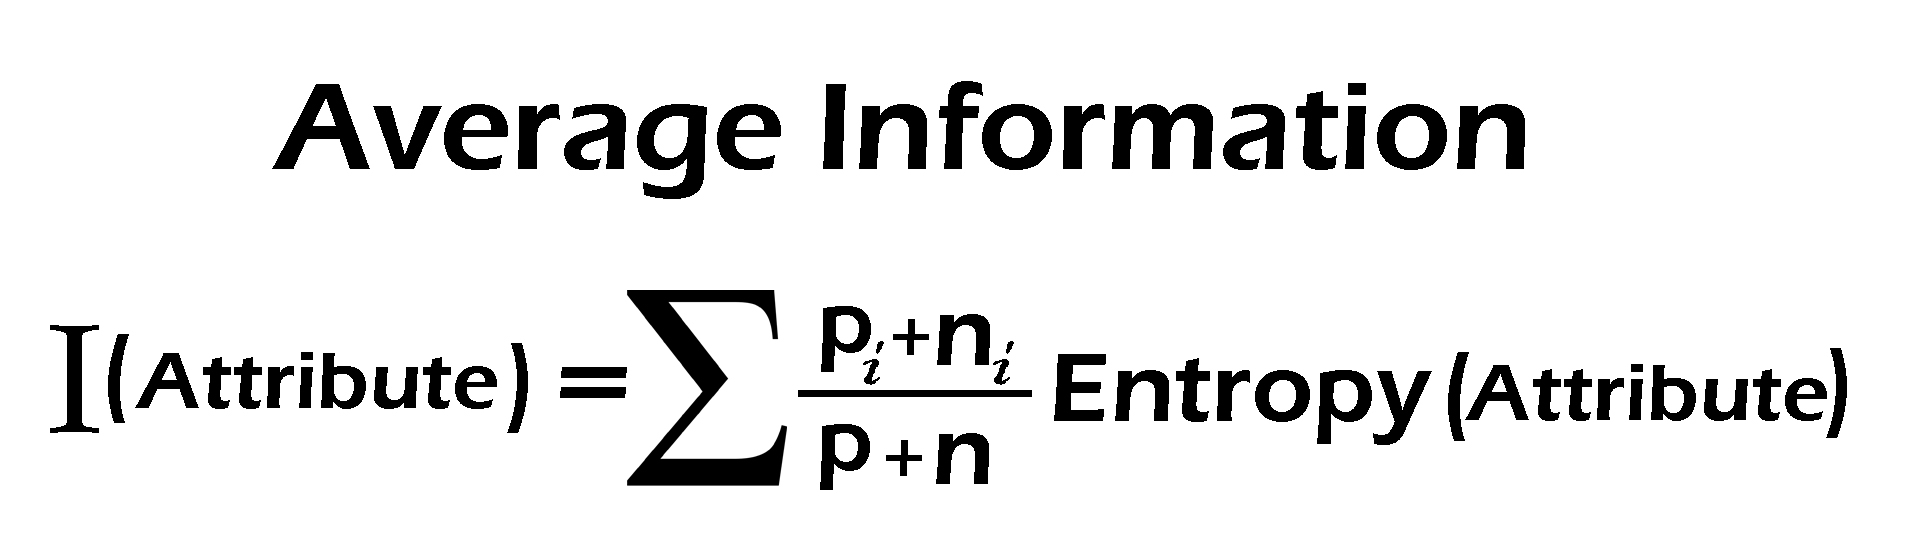

In [8]:
def average_information(df,attribute):
    
    values = df[attribute].unique()
    #print(values)
    count = len(values)
    #print(count)
    total = df.shape[0]

    totalGain = 0
    
    for i in range(count):
        elementCount = df[df[attribute] == values[i]].shape[0]
        print(elementCount)
        subset = df[df[attribute] == values[i]]
        print(subset)

        totalGain += (elementCount/total)*find_entropy(subset)

    avg_entropy_value = totalGain/count

    return avg_entropy_value


In [9]:
def find_winner(df):
    IG = []
    for key in df.keys()[:-1]:
        IG.append(find_entropy(df)-average_information(df,key))

    #print(IG)
    return df.keys()[:-1][np.argmax(IG)]

In [10]:
def get_subtable(df, node,value):
  return df[df[node] == value].reset_index(drop=True)

In [11]:
def buildTree(df,tree=None):
    target = df.keys()[-1]   #target column

    #Here we build our decision tree

    #Get attribute with maximum information gain
    node = find_winner(df)
    print(node)

    #Get distinct value of that attribute e.g Salary is node and Low,Med and High are values
    attValue = np.unique(df[node])

    #Create an empty dictionary to create tree
    if tree is None:
        tree={}
        tree[node] = {}

    #We make loop to construct a tree by calling this function recursively.
    #In this we check if the subset is pure and stops if it is pure.

    for value in attValue:

        subtable = get_subtable(df,node,value)
        clValue,counts = np.unique(subtable[target],return_counts=True)

        if len(counts)==1:#Checking purity of subset
            tree[node][value] = clValue[0]
            
        else:
            tree[node][value] = buildTree(subtable) #Calling the function recursively

    return tree

In [12]:
#build Tree
tree = buildTree(df2)

4
   outlook  temp  humidity  wind  playtennis
0        2     1         0     1           0
1        2     1         0     0           0
7        2     2         0     1           0
8        2     0         1     1           1
2
   outlook  temp  humidity  wind  playtennis
2        0     1         0     1           1
6        0     0         1     0           1
4
   outlook  temp  humidity  wind  playtennis
3        1     2         0     1           1
4        1     0         1     1           1
5        1     0         1     0           0
9        1     2         1     1           1
3
   outlook  temp  humidity  wind  playtennis
0        2     1         0     1           0
1        2     1         0     0           0
2        0     1         0     1           1
3
   outlook  temp  humidity  wind  playtennis
3        1     2         0     1           1
7        2     2         0     1           0
9        1     2         1     1           1
4
   outlook  temp  humidity  wind  playtenni

In [14]:
import pprint
pprint.pprint(tree)

{'outlook': {0: 1, 1: {'wind': {0: 0, 1: 1}}, 2: {'temp': {0: 1, 1: 0, 2: 0}}}}
